In [75]:
from pathlib import Path
from itertools import product
import sys
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display

sys.path.append(os.path.abspath("../"))

from simulators.model_solver_real_data import SoftFireCA
from simulators.metrics import FireMetrics

# In this notebook, we will try to find the parameters alpha beta gamma and study their sensitivity on real data.

# Load and prepare the data

In [ ]:
REAL_DATA_DIR = Path("../data/backtest/fire_example_45")

temp = np.load(REAL_DATA_DIR / "2022-07-12_temperature.npy")
wind_dir = np.load(REAL_DATA_DIR / "2022-07-12_wind_direction.npy")
wind_val = np.load(REAL_DATA_DIR / "2022-07-12_wind_val.npy")
humidity = np.load(REAL_DATA_DIR / "2022-07-13_humidity.npy")
height_grid = np.load(REAL_DATA_DIR / "altitude.npy")
ground = np.load(REAL_DATA_DIR / "ground_matrix.npy", allow_pickle=True)
fire_spread = np.load(REAL_DATA_DIR / "fire_spread.npy")

height_grid = height_grid.astype(np.float32)
wind_speed = wind_val.astype(np.float32)


if wind_speed.max() != wind_speed.min():
    wind_grid = ((wind_speed - wind_speed.min()) / (wind_speed.max() - wind_speed.min())).astype(np.float32)
else:
    wind_grid = np.zeros_like(wind_speed, dtype=np.float32)

non_burnable = ["water", "bay", "sand", "dune", "wetland", "military"]
forest = 1 - np.isin(ground, non_burnable).astype(np.float32)

N_FRAMES = len(fire_spread)
TIME_EVAL = N_FRAMES - 1

print("fire_spread:", fire_spread.shape, fire_spread.min(), fire_spread.max())
print("height_grid:", height_grid.shape, height_grid.min(), height_grid.max())
print("wind_grid:", wind_grid.shape, wind_grid.min(), wind_grid.max())
print("forest:", forest.shape, forest.min(), forest.max(), "burnable ratio:", forest.mean())

fire_spread: (7, 54, 54) 0.0 1.0
height_grid: (54, 54) 204.0 317.0
wind_grid: (54, 54) 0.0 1.0
forest: (54, 54) 0.0 1.0 burnable ratio: 0.6920439


In [77]:
LAND_PARAMS = {
    "bay":           (0.95,     0),
    "beach":         (0.30,     0),
    "brownfield":    (0.10,     0),
    "cemetery":      (0.35,    10),
    "coastline":     (0.70,     2),
    "dune":          (0.15,     3),
    "empty":         (0.10,     0),
    "forest":        (0.50,    40),
    "grass":         (0.30,     5),
    "grassland":     (0.30,     8),
    "industrial":    (0.05,     0),
    "meadow":        (0.45,    10),
    "military":      (0.20,     5),
    "residential":   (0.20,     5),
    "sand":          (0.10,     0),
    "scrub":         (0.25,    15),
    "tree":          (0.45,    25),
    "water":         (1.00,     0),
    "wetland":       (0.90,     5),
}


def ground_to_grids(ground, land_params=LAND_PARAMS):
    moisture_vals = np.array([v[0] for v in land_params.values()], dtype=np.float32)
    age_vals = np.array([v[1] for v in land_params.values()], dtype=np.float32)
    keys = list(land_params.keys())

    key_to_idx = {k: i for i, k in enumerate(keys)}
    idx_grid = np.vectorize(lambda x: key_to_idx.get(x, 0))(ground)

    return moisture_vals[idx_grid], age_vals[idx_grid]


moisture_grid, age_grid = ground_to_grids(ground)

moisture_grid = moisture_grid.astype(np.float32)
age_grid = age_grid.astype(np.float32)

print("moisture_grid:", moisture_grid.shape, moisture_grid.min(), moisture_grid.max())
print("age_grid:", age_grid.shape, age_grid.min(), age_grid.max())

moisture_grid: (54, 54) 0.05 1.0
age_grid: (54, 54) 0.0 40.0


In [78]:
ignition_point = [
    fire_spread[0].argmax() // fire_spread[0].shape[0],
    fire_spread[0].argmax() % fire_spread[0].shape[0],
]

ignition_value = fire_spread[0][ignition_point[0], ignition_point[1]]

FM_obs = FireMetrics(fire_spread, fire_spread)
arrival_time = FM_obs.arrival_time_G
arrival_time[np.isinf(arrival_time)] = -1
arrival_time = arrival_time.astype(np.float32)

print("Ignition point:", ignition_point)
print("Ignition value:", ignition_value)
print("arrival_time shape:", arrival_time.shape)
print("arrival_time min/max:", arrival_time.min(), arrival_time.max())
print("burned cells in ground truth:", int((arrival_time >= 0).sum()))

Ignition point: [np.int64(21), np.int64(28)]
Ignition value: 7.841371225840634e-05
arrival_time shape: (54, 54)
arrival_time min/max: -1.0 6.0
burned cells in ground truth: 1461


### Utilitary functions

In [79]:
def arrival_to_sequence(arrival, n_steps):
    if isinstance(arrival, torch.Tensor):
        arrival = arrival.detach().cpu().numpy()
    else:
        arrival = np.array(arrival)

    H, W = arrival.shape
    sequence = np.zeros((n_steps, H, W), dtype=np.float32)

    for t in range(1, n_steps):
        burned = (arrival <= t) & (arrival > t - 1)
        sequence[t] = sequence[t - 1] + burned.astype(np.float32)

    return sequence


def clean_predicted_arrival(arrival_prediction, max_time):
    if isinstance(arrival_prediction, torch.Tensor):
        arrival_prediction = arrival_prediction.detach().cpu().numpy()

    arrival_prediction = np.array(arrival_prediction, dtype=np.float32)
    arrival_prediction[~np.isfinite(arrival_prediction)] = -1
    arrival_prediction[arrival_prediction > max_time] = -1
    arrival_prediction = np.round(arrival_prediction)

    return arrival_prediction.astype(np.float32)


def iou_score(pred, obs):
    pred = np.asarray(pred, dtype=np.float32)
    obs = np.asarray(obs, dtype=np.float32)

    intersection = np.minimum(pred, obs).sum()
    union = np.maximum(pred, obs).sum()

    if union == 0.0:
        return 1.0

    return float(intersection / union)


def aatd_from_maps_safe(pred_arrival, obs_arrival):
    pred_arrival = np.asarray(pred_arrival, dtype=np.float32)
    obs_arrival = np.asarray(obs_arrival, dtype=np.float32)

    valid = (pred_arrival >= 0) & (obs_arrival >= 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.mean(np.abs(pred_arrival[valid] - obs_arrival[valid])))

In [80]:
def simulate_fire_candidate_softca(
    height_grid,
    age_grid,
    moisture_grid,
    wind_grid,
    ignition_point,
    ignition_value,
    alpha,
    beta,
    gamma,
    n_frames=N_FRAMES,
    n_substeps=5,
    burn_mask=forest,
):
    model = SoftFireCA(
        height_grid,
        age_grid,
        moisture_grid,
        alpha_init=alpha,
        beta_init=beta,
        gamma_init=gamma,
        burn_mask=burn_mask,
    )

    model.eval()

    with torch.no_grad():
        arrival_prediction = model.forward(
            ignition_point,
            ignition_value,
            wind_grid,
            n_frames,
            n_substeps,
        )

    pred_sequence = arrival_to_sequence(arrival_prediction, n_frames)
    pred_final = pred_sequence[-1].astype(np.float32)

    pred_arrival_clean = clean_predicted_arrival(
        arrival_prediction,
        max_time=n_frames - 1,
    )

    return {
        "arrival_prediction": arrival_prediction,
        "arrival_time": pred_arrival_clean,
        "sequence": pred_sequence,
        "final_state": pred_final,
    }

In [81]:
def evaluate_softca_params(
    alpha,
    beta,
    gamma,
    n_substeps=5,
    time_eval=TIME_EVAL,
):
    pred = simulate_fire_candidate_softca(
        height_grid=height_grid,
        age_grid=age_grid,
        moisture_grid=moisture_grid,
        wind_grid=wind_grid,
        ignition_point=ignition_point,
        ignition_value=ignition_value,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        n_frames=N_FRAMES,
        n_substeps=n_substeps,
        burn_mask=forest,
    )

    pred_sequence = pred["sequence"]
    pred_final = pred["final_state"]
    pred_arrival = pred["arrival_time"]

    obs_final = fire_spread[-1].astype(np.float32)

    iou = iou_score(pred_final, obs_final)
    aatd = aatd_from_maps_safe(pred_arrival, arrival_time)

    try:
        FM = FireMetrics(pred_sequence, fire_spread)
        shape_metrics = FM.all_shape_metrics(time_eval, time_eval)
        spread_metrics = FM.all_spread_metrics()
        metrics = shape_metrics | spread_metrics
    except Exception as e:
        metrics = {"firemetrics_error": str(e)}

    metrics.update(
        {
            "alpha": float(alpha),
            "beta": float(beta),
            "gamma": float(gamma),
            "n_substeps": int(n_substeps),
            "mean_iou": float(iou),
            "mean_iou_loss": float(1.0 - iou),
            "mean_aatd": float(aatd) if np.isfinite(aatd) else np.nan,
        }
    )

    return metrics

# Grid search

In [ ]:
alpha_grid = [0.05, 0.1, 0.3, 0.5, 0.8, 1.2, 1.5,2 ,3]
beta_grid = [0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 0.8, 1.2]
gamma_grid = [0.005, 0.01, 0.03, 0.05, 0.1, 0.3, 0.8]

n_substeps_grid = [5]

n_candidates = len(alpha_grid) * len(beta_grid) * len(gamma_grid) * len(n_substeps_grid)

print("Nombre de combinaisons:", n_candidates)

results = []

counter = 0

for alpha, beta, gamma, n_substeps in product(
    alpha_grid,
    beta_grid,
    gamma_grid,
    n_substeps_grid,
):
    counter += 1

    print(
        f"[{counter}/{n_candidates}] "
        f"alpha={alpha}, beta={beta}, gamma={gamma}, n_substeps={n_substeps}"
    )

    try:
        row = evaluate_softca_params(
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            n_substeps=n_substeps,
            time_eval=TIME_EVAL,
        )
        results.append(row)

    except Exception as e:
        print("Erreur:", e)

results_df = pd.DataFrame(results)

display(results_df.head())
print(results_df.columns.tolist())

Nombre de combinaisons: 504
[1/504] alpha=0.05, beta=0.005, gamma=0.005, n_substeps=5
[2/504] alpha=0.05, beta=0.005, gamma=0.01, n_substeps=5
[3/504] alpha=0.05, beta=0.005, gamma=0.03, n_substeps=5
[4/504] alpha=0.05, beta=0.005, gamma=0.05, n_substeps=5
[5/504] alpha=0.05, beta=0.005, gamma=0.1, n_substeps=5
[6/504] alpha=0.05, beta=0.005, gamma=0.3, n_substeps=5
[7/504] alpha=0.05, beta=0.005, gamma=0.8, n_substeps=5
[8/504] alpha=0.05, beta=0.01, gamma=0.005, n_substeps=5
[9/504] alpha=0.05, beta=0.01, gamma=0.01, n_substeps=5
[10/504] alpha=0.05, beta=0.01, gamma=0.03, n_substeps=5
[11/504] alpha=0.05, beta=0.01, gamma=0.05, n_substeps=5
[12/504] alpha=0.05, beta=0.01, gamma=0.1, n_substeps=5
[13/504] alpha=0.05, beta=0.01, gamma=0.3, n_substeps=5
[14/504] alpha=0.05, beta=0.01, gamma=0.8, n_substeps=5
[15/504] alpha=0.05, beta=0.03, gamma=0.005, n_substeps=5
[16/504] alpha=0.05, beta=0.03, gamma=0.01, n_substeps=5
[17/504] alpha=0.05, beta=0.03, gamma=0.03, n_substeps=5
[18/504]

,iou,l2_norm,wasserstein2,hausdorff,aatd,fde_radians,fde_degrees,alpha,beta,gamma,n_substeps,mean_iou,mean_iou_loss,mean_aatd
0,0.796785,0.327428,2.046728,5.0,1.387982,0.905791,51.897992,0.05,0.005,0.005,5,0.796785,0.203215,1.359792
1,0.798200,0.325853,2.021162,5.0,1.389466,0.919334,52.673976,0.05,0.005,0.010,5,0.798200,0.201800,1.359792
2,0.801143,0.322230,1.977260,5.0,1.394052,0.858396,49.182469,0.05,0.005,0.030,5,0.801143,0.198857,1.368773
3,0.804906,0.317605,1.983089,5.0,1.399404,0.929888,53.278675,0.05,0.005,0.050,5,0.804906,0.195094,1.368852
4,0.806032,0.314729,2.045464,6.0,1.398796,0.849639,48.680702,0.05,0.005,0.100,5,0.806032,0.193968,1.383747


['iou', 'l2_norm', 'wasserstein2', 'hausdorff', 'aatd', 'fde_radians', 'fde_degrees', 'alpha', 'beta', 'gamma', 'n_substeps', 'mean_iou', 'mean_iou_loss', 'mean_aatd']


## Analysis of the results

In [91]:
sort_metric = "mean_iou_loss"

results_df_sorted = (
    results_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[sort_metric])
    .sort_values(sort_metric)
    .reset_index(drop=True)
)

display(results_df_sorted.head(20))

best = results_df_sorted.iloc[0]

best_alpha = float(best["alpha"])
best_beta = float(best["beta"])
best_gamma = float(best["gamma"])
best_substeps = int(best["n_substeps"])

print("Best parameters:")
print(f"alpha      = {best_alpha}")
print(f"beta       = {best_beta}")
print(f"gamma      = {best_gamma}")
print(f"n_substeps = {best_substeps}")
print(f"mean_iou      = {best['mean_iou']}")
print(f"mean_iou_loss = {best['mean_iou_loss']}")
print(f"mean_aatd     = {best['mean_aatd']}")

,iou,l2_norm,wasserstein2,hausdorff,aatd,fde_radians,fde_degrees,alpha,beta,gamma,n_substeps,mean_iou,mean_iou_loss,mean_aatd
0,0.827303,0.288471,2.102868,6.000000,1.489718,0.860798,49.320095,0.8,0.300,0.010,5,0.827303,0.172697,1.460015
1,0.826150,0.289885,2.118438,6.000000,1.488584,0.839410,48.094666,0.8,0.300,0.005,5,0.826150,0.173850,1.460426
2,0.825675,0.289301,2.154394,6.324555,1.490421,0.846463,48.498782,0.8,0.300,0.030,5,0.825675,0.174325,1.470498
3,0.825259,0.290689,2.155040,7.000000,1.460366,0.867044,49.677986,0.8,0.100,0.100,5,0.825259,0.174741,1.424543
4,0.823513,0.293555,2.116440,6.324555,1.445372,0.865328,49.579665,0.8,0.050,0.100,5,0.823513,0.176487,1.415023
5,0.822707,0.294721,2.115906,6.082763,1.442424,0.857363,49.123299,0.8,0.030,0.100,5,0.822707,0.177293,1.407576
6,0.822132,0.291947,2.207964,7.000000,1.498069,0.848443,48.612186,0.8,0.300,0.050,5,0.822132,0.177868,1.471815
7,0.822030,0.296942,2.165693,4.472136,1.429535,0.952346,54.565435,1.2,0.030,0.010,5,0.822030,0.177970,1.392054
8,0.821905,0.295882,2.100698,6.000000,1.432678,0.831675,47.651494,0.8,0.010,0.100,5,0.821905,0.178095,1.403177
9,0.821905,0.295882,2.100698,6.000000,1.431921,0.831675,47.651494,0.8,0.005,0.100,5,0.821905,0.178095,1.403177


Best parameters:
alpha      = 0.8
beta       = 0.3
gamma      = 0.01
n_substeps = 5
mean_iou      = 0.8273029327392578
mean_iou_loss = 0.1726970672607422
mean_aatd     = 1.4600151777267456


# Visualisations

IoU final: 0.8273029327392578
Observed final min/max: 0.0 1.0
Predicted final min/max: 0.0 1.0
Observed burned cells > 0: 1580
Predicted burned cells > 0: 1437


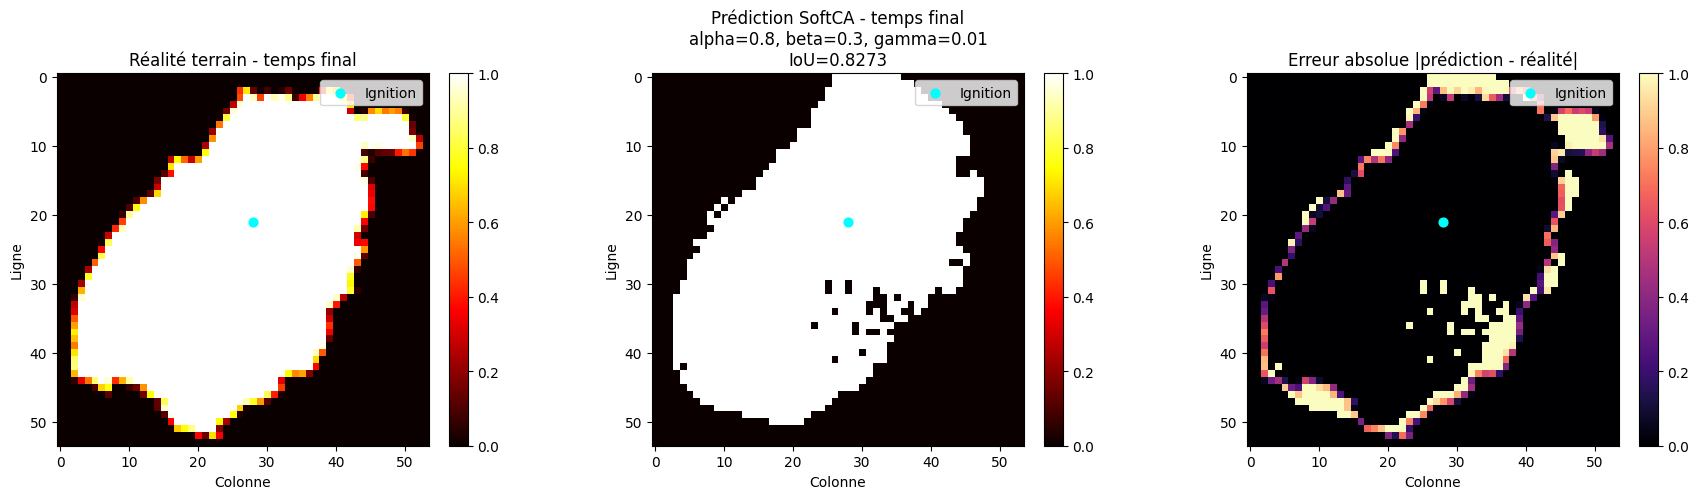

In [92]:
best_pred = simulate_fire_candidate_softca(
    height_grid=height_grid,
    age_grid=age_grid,
    moisture_grid=moisture_grid,
    wind_grid=wind_grid,
    ignition_point=ignition_point,
    ignition_value=ignition_value,
    alpha=best_alpha,
    beta=best_beta,
    gamma=best_gamma,
    n_frames=N_FRAMES,
    n_substeps=best_substeps,
    burn_mask=forest,
)

pred_final = best_pred["final_state"].astype(np.float32)
obs_final = fire_spread[-1].astype(np.float32)

final_iou = iou_score(pred_final, obs_final)

i0, j0 = int(ignition_point[0]), int(ignition_point[1])

print("IoU final:", final_iou)
print("Observed final min/max:", obs_final.min(), obs_final.max())
print("Predicted final min/max:", pred_final.min(), pred_final.max())
print("Observed burned cells > 0:", int((obs_final > 0).sum()))
print("Predicted burned cells > 0:", int((pred_final > 0).sum()))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

im0 = axs[0].imshow(obs_final, cmap="hot", vmin=0, vmax=1)
axs[0].scatter([j0], [i0], c="cyan", s=40, label="Ignition")
axs[0].set_title("Réalité terrain - temps final")
axs[0].set_xlabel("Colonne")
axs[0].set_ylabel("Ligne")
axs[0].legend(loc="upper right")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(pred_final, cmap="hot", vmin=0, vmax=1)
axs[1].scatter([j0], [i0], c="cyan", s=40, label="Ignition")
axs[1].set_title(
    f"Prédiction SoftCA - temps final\n"
    f"alpha={best_alpha}, beta={best_beta}, gamma={best_gamma}\n"
    f"IoU={final_iou:.4f}"
)
axs[1].set_xlabel("Colonne")
axs[1].set_ylabel("Ligne")
axs[1].legend(loc="upper right")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

diff = np.abs(pred_final - obs_final)

im2 = axs[2].imshow(diff, cmap="magma", vmin=0, vmax=1)
axs[2].scatter([j0], [i0], c="cyan", s=40, label="Ignition")
axs[2].set_title("Erreur absolue |prédiction - réalité|")
axs[2].set_xlabel("Colonne")
axs[2].set_ylabel("Ligne")
axs[2].legend(loc="upper right")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Heatmaps

In [95]:

metric_to_plot = "mean_iou"  # plus grand = meilleur

best_for_heatmap = (
    results_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[metric_to_plot])
    .sort_values(metric_to_plot, ascending=False)
    .iloc[0]
)

fixed_alpha = float(best_for_heatmap["alpha"])
fixed_beta = float(best_for_heatmap["beta"])
fixed_gamma = float(best_for_heatmap["gamma"])

if "n_substeps" in results_df.columns:
    fixed_substeps = int(best_for_heatmap["n_substeps"])
else:
    fixed_substeps = None

print("Meilleur point selon IoU :")
print(f"alpha = {fixed_alpha}")
print(f"beta  = {fixed_beta}")
print(f"gamma = {fixed_gamma}")

if fixed_substeps is not None:
    print(f"n_substeps = {fixed_substeps}")

print(f"IoU = {best_for_heatmap['mean_iou']}")

Meilleur point selon IoU :
alpha = 0.8
beta  = 0.3
gamma = 0.01
n_substeps = 5
IoU = 0.8273029327392578


In [96]:
def plot_param_heatmap_iou(
    df,
    x_param,
    y_param,
    fixed_param,
    fixed_value,
    fixed_substeps=None,
):
    df_plot = df.copy()

    if fixed_substeps is not None and "n_substeps" in df_plot.columns:
        df_plot = df_plot[df_plot["n_substeps"] == fixed_substeps]

    df_plot = df_plot[np.isclose(df_plot[fixed_param], fixed_value)]

    if df_plot.empty:
        print(f"Aucune donnée pour {fixed_param} = {fixed_value}")
        return

    heatmap = df_plot.pivot_table(
        index=y_param,
        columns=x_param,
        values="mean_iou",
        aggfunc="mean",
    )

    if heatmap.empty:
        print(f"Heatmap vide pour {x_param}/{y_param} avec {fixed_param}={fixed_value}")
        return

    x_values = heatmap.columns.values
    y_values = heatmap.index.values

    plt.figure(figsize=(8, 6))

    im = plt.imshow(
        heatmap.values,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
    )

    plt.xticks(
        ticks=np.arange(len(x_values)),
        labels=[f"{v:g}" for v in x_values],
        rotation=45,
    )

    plt.yticks(
        ticks=np.arange(len(y_values)),
        labels=[f"{v:g}" for v in y_values],
    )

    plt.xlabel(x_param)
    plt.ylabel(y_param)

    title = f"IoU pour {y_param} / {x_param}\n{fixed_param} fixé à {fixed_value:g}"

    if fixed_substeps is not None:
        title += f", n_substeps={fixed_substeps}"

    plt.title(title)
    plt.colorbar(im, label="mean_iou")

    best_x = float(best_for_heatmap[x_param])
    best_y = float(best_for_heatmap[y_param])

    x_match = np.where(np.isclose(x_values.astype(float), best_x))[0]
    y_match = np.where(np.isclose(y_values.astype(float), best_y))[0]

    if len(x_match) > 0 and len(y_match) > 0:
        plt.scatter(
            x_match[0],
            y_match[0],
            c="red",
            s=90,
            marker="x",
            label="meilleur IoU",
        )
        plt.legend()

    plt.tight_layout()
    plt.show()

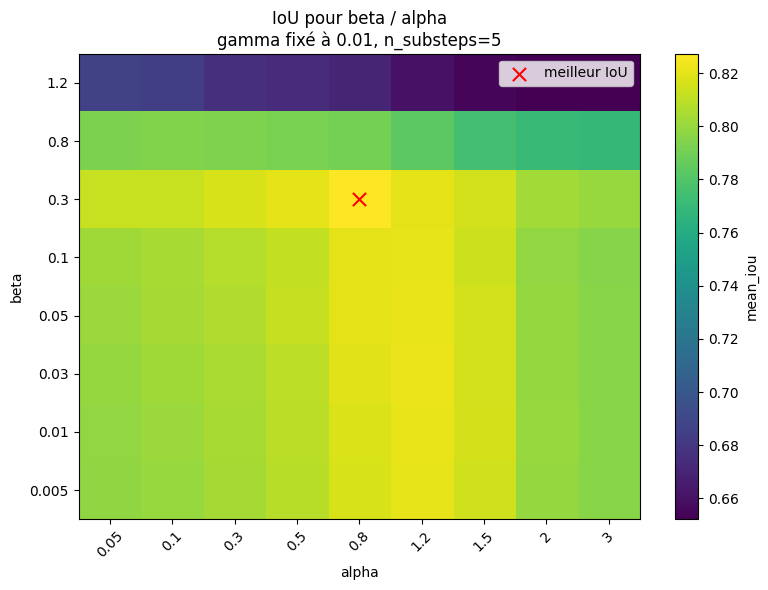

In [97]:
# Heatmap alpha / beta avec gamma fixé au meilleur gamma IoU

plot_param_heatmap_iou(
    df=results_df,
    x_param="alpha",
    y_param="beta",
    fixed_param="gamma",
    fixed_value=fixed_gamma,
    fixed_substeps=fixed_substeps,
)

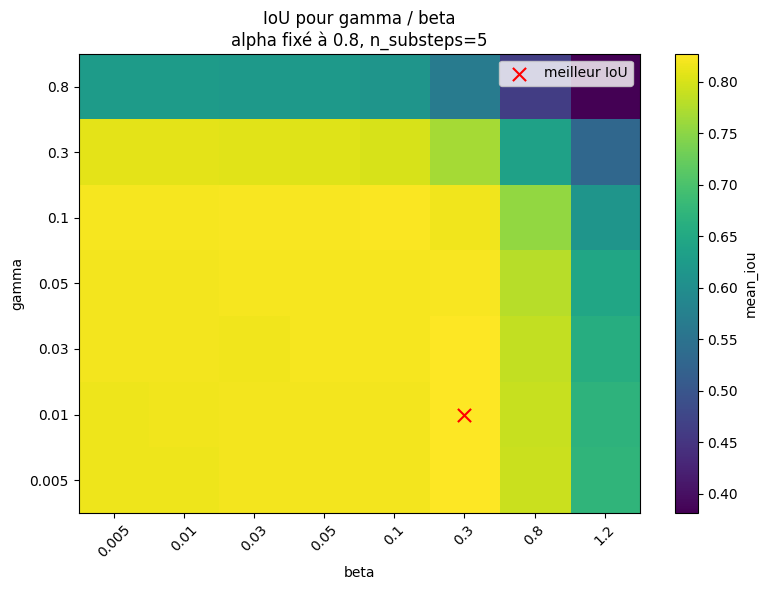

In [98]:
# Heatmap beta / gamma avec alpha fixé au meilleur alpha IoU

plot_param_heatmap_iou(
    df=results_df,
    x_param="beta",
    y_param="gamma",
    fixed_param="alpha",
    fixed_value=fixed_alpha,
    fixed_substeps=fixed_substeps,
)

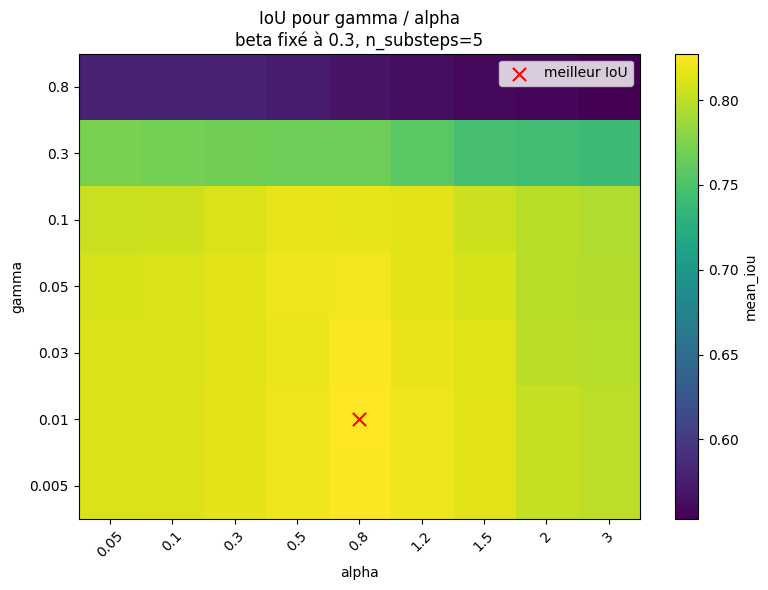

In [100]:
# Heatmap alpha / gamma avec beta fixé au meilleur beta IoU

plot_param_heatmap_iou(
    df=results_df,
    x_param="alpha",
    y_param="gamma",
    fixed_param="beta",
    fixed_value=fixed_beta,
    fixed_substeps=fixed_substeps,
)